# W3D3 — Backpropagation from Scratch — Lab

**Week 3 · Day 3 · Deep Learning & Neural Networks** · Lab

This is the hardest lab of the bootcamp, and the one that pays for the rest of it. A student who
finishes task 2.3 understands what every framework is doing on their behalf — and, more usefully,
knows how to check whether it is doing it correctly.

Four things, in order:

- **Measure a gradient.** Nudge one weight by 0.01, run the forward pass again, divide the change in
  loss by the change in the weight. That is the whole idea, and it is the lecture's `−0.134`.
- **Write the loss.** Binary cross-entropy, on two predictions of the same true label, and the ratio
  between them: 22, not 2.
- **Write the backward pass**, and then **check every single gradient against the numerical one.**
  Not one of them. All 33. This is the task; protect its time.
- **Train it.** 2,000 iterations, a loss curve that falls, and a decision boundary that curves around
  a moon — beside yesterday's smear, in the same figure.

You leave with `numpy_net_history.parquet` and `numpy_net_params.npz`. Tomorrow PyTorch reproduces
both, from the same starting weights, to six decimals.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٣ اليوم ٣ — الانتشار الخلفي من الصفر

**الأسبوع ٣ · اليوم ٣ · التعلّم العميق والشبكات العصبية** · معمل عملي

هذا أصعب معامل في المعسكر، وهو الذي يدفع ثمن بقيتها. والطالب الذي يُكمل المهمة ٢٫٣ يفهم ما تفعله عنه
كل مكتبة — والأنفع أنه يعرف كيف يتحقّق أنها تفعله بصواب.

وأربعة أمور بالترتيب:

- **قِس اشتقاقًا.** حرّك وزنًا واحدًا بمقدار ٠٫٠١، وأعِد المرور الأمامي، واقسم تغيّر الخسارة على
  تغيّر الوزن. هذه هي الفكرة كلها، وهي `−0.134` في المحاضرة.
- **اكتب دالة الخسارة.** الانتروبيا التقاطعية الثنائية على تنبّؤين للتصنيف الصحيح نفسه، والنسبة
  بينهما: ٢٢ لا ٢.
- **اكتب المرور الخلفي**، ثم **افحص كل اشتقاق مقابل نظيره العددي.** لا واحدًا منها بل الثلاثة
  والثلاثين كلها. وهذه هي المهمة، فاحمِ وقتها.
- **درّبها.** ألفا تكرار ومنحنى خسارة يهبط وحدّ قرار ينحني حول هلال — بجانب لطخة الأمس في الشكل نفسه.

ستخرج بملفَّي `numpy_net_history.parquet` و`numpy_net_params.npz`. وغدًا يُعيد PyTorch إنتاجهما من
الأوزان الابتدائية نفسها إلى ست خانات عشرية.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Measure the gradient of a loss with respect to one weight by nudging it, and read its sign as a
  direction.
- Say why a central difference is more accurate than a one-sided one, having computed both.
- Implement binary cross-entropy, and say why a confident wrong answer costs 22 times a hesitant one
  rather than twice.
- Write a backward pass for a two-layer network, returning a gradient for every parameter.
- **Verify** a backward pass against numerical gradients, parameter by parameter — the single most
  useful debugging skill in this course.
- Train a network with gradient descent and read its loss curve.
- Show that your trained network's boundary is non-linear, by beating a fitted logistic regression on
  the same data.
- Say what backpropagation actually saves, as a measured ratio rather than a claim.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- قياس اشتقاق الخسارة بالنسبة لوزن واحد بتحريكه، وقراءة إشارته كاتجاه.
- بيان لماذا يكون الفرق المركزي أدقّ من الفرق أحادي الجهة، بعد أن حسبت الاثنين.
- تنفيذ الانتروبيا التقاطعية الثنائية، وبيان لماذا يكلّف الجواب الخطأ الواثق ٢٢ ضعف الجواب المتردّد
  لا ضعفين.
- كتابة مرور خلفي لشبكة ذات طبقتين يُرجع اشتقاقًا لكل معامل.
- **التحقّق** من المرور الخلفي مقابل الاشتقاقات العددية، معاملًا معاملًا — وهي أنفع مهارة تصحيح في
  هذه الدورة.
- تدريب شبكة بطريقة النزول التدريجي وقراءة منحنى خسارتها.
- إظهار أن حدّ شبكتك المُدرَّبة غير خطي، بتجاوز انحدار لوجستي مُدرَّب على البيانات نفسها.
- بيان ما يوفّره الانتشار الخلفي فعلًا، كنسبة مقيسة لا كادّعاء.

</div>


## About the data

**Dataset:** `moons_toy` — 500 rows × 3 columns, the same file as yesterday, CC0

Two coordinates and a binary label; two interleaving half-moons with `noise=0.2`. Yesterday you ran
it through an untrained network and got a straight smear and 0.64 accuracy. Today the same 500 rows
train the same network, and by the end the boundary bends around each moon.

The ceiling is about 0.98, not 1.00 — the moons genuinely overlap, and a handful of points sit on the
wrong side of any boundary you could draw. **If you score 1.00, you have a bug.**

You also load **`forward_check.json`** from yesterday. Its job is to confirm, before you write
anything new, that your forward pass still produces the slide's `0.8176`. If that number has moved,
the bug is in the code you are about to write on top of it, and you will know in the first two
minutes.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `moons_toy` — ٥٠٠ صف × ٣ أعمدة، الملف نفسه بالأمس، رخصة CC0

إحداثيان وتصنيف ثنائي؛ هلالان متداخلان بضوضاء `noise=0.2`. وبالأمس مرّرتها في شبكة غير مُدرَّبة فحصلت
على لطخة مستقيمة ودقة ٠٫٦٤. واليوم تُدرّب الصفوف الخمسمئة نفسها الشبكة نفسها، وبالنهاية ينحني الحدّ
حول كل هلال.

والسقف نحو ٠٫٩٨ لا ١٫٠٠ — فالهلالان متداخلان فعلًا، وبضع نقاط تقع في الجهة الخطأ من أي حدّ ترسمه.
**فإن سجّلت ١٫٠٠ فعندك عيب.**

وتُحمّل أيضًا **`forward_check.json`** من الأمس. ووظيفته أن يؤكّد — قبل أن تكتب أي شيء جديد — أن
مرورك الأمامي ما زال يُنتج `0.8176` كما في الشريحة. فإن تحرّك ذلك الرقم فالعيب في الشيفرة التي أنت
على وشك كتابتها فوقه، وستعرف ذلك في أول دقيقتين.

</div>


## Setup

Run the cell below first. It loads the data, re-creates yesterday's `init_params` and `forward`
exactly as you wrote them, and re-checks them against yesterday's artefact.

`forward` is given to you today on purpose. You wrote it yesterday, it is not what is being taught
now, and the backward pass is going to need all of your remaining time.

<div dir="rtl" align="right">

## الإعداد

شغّل الخليّة أدناه أولًا. تُحمّل البيانات وتُعيد إنشاء `init_params` و`forward` من الأمس كما كتبتهما
بالضبط، وتُعيد فحصهما مقابل مخرجات الأمس.

و`forward` معطاة لك اليوم عن قصد. فقد كتبتها بالأمس، وليست هي ما يُدرَّس الآن، والمرور الخلفي سيحتاج
كل ما تبقّى من وقتك.

</div>


In [45]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset, load_artefact
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("scikit-learn", "matplotlib", "pyarrow")
seed_everything(42)

import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from aiep.viz import use_course_style, PALETTE
use_course_style()

moons = pd.read_parquet(get_dataset("moons_toy"))
X = moons[["x1", "x2"]].to_numpy()
y = moons["label"].to_numpy().reshape(-1, 1).astype(float)

N_IN, N_HIDDEN, N_OUT = 2, 8, 1
SEED = 42


# --- yesterday's code, unchanged ---------------------------------------------------
def relu(z):
    return np.maximum(0, z)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def init_params(n_in, n_hidden, n_out, seed=SEED):
    rng = np.random.default_rng(seed)
    return {"W1": rng.normal(0, np.sqrt(2 / n_in), size=(n_in, n_hidden)),
            "b1": np.zeros(n_hidden),
            "W2": rng.normal(0, np.sqrt(2 / n_hidden), size=(n_hidden, n_out)),
            "b2": np.zeros(n_out)}


def forward(params, X):
    """Returns (output, cache). The cache is what today's backward pass consumes."""
    z1 = X @ params["W1"] + params["b1"]
    a1 = relu(z1)
    z2 = a1 @ params["W2"] + params["b2"]
    return sigmoid(z2), {"z1": z1, "a1": a1, "z2": z2}


LECTURE = {"W1": np.array([[0.5, -0.5], [1.0, 0.5]]),
           "b1": np.array([0.0, 0.5]),
           "W2": np.array([[1.0], [-1.0]]),
           "b2": np.array([0.0])}

# Yesterday's artefact, re-checked before anything new is built on it.
yesterday = json.loads(load_artefact("forward_check.json").read_text(encoding="utf-8"))
today_out, _ = forward(LECTURE, np.array([[1.0, 2.0]]))
print(f"yesterday's recorded output: {yesterday['lecture_network']['output']:.6f}")
print(f"the same forward pass today: {today_out[0, 0]:.6f}")
print(f"unchanged: {np.isclose(today_out[0, 0], yesterday['lecture_network']['output'])}")
print(f"\nX {X.shape} | y {y.shape} | network {N_IN}-{N_HIDDEN}-{N_OUT}")
print("\n", versions())

📁 moons_toy: using cached file at C:\Users\pc\AIEP_Olo_student\AIEP_Olo_student\shared\data_cache\moons_toy.parquet
ℹ️  Using the reference copy of forward_check.json from solutions_cache (you don't have a local one yet).
   نستخدم النسخة المرجعية من forward_check.json لعدم وجود نسخة محلية لديك.
yesterday's recorded output: 0.817574
the same forward pass today: 0.817574
unchanged: True

X (500, 2) | y (500, 1) | network 2-8-1

 python 3.11.16 | numpy 2.0.2 | pandas 3.0.5 | scikit-learn 1.9.0 | torch 2.13.0+cpu | transformers 5.15.1


## Section 1 — Warm-up: measure one gradient  (≈25 min)

Everything in this section already works.

The lecture's network, the lecture's input, the lecture's target. The output was `0.8176` and the
target was `1.0`, so the squared error is `(0.8176 − 1.0)² = 0.0333`. That is the loss, and it is
today's starting number.

Now the only question that matters: **if I raise `W2[0]` a little, does that number go up or down?**

There is a way to answer it that requires no calculus at all. Change the weight. Run the forward pass
again. Look at the loss. Divide.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: قِس اشتقاقًا واحدًا (نحو ٢٥ دقيقة)

كل ما في هذا القسم يعمل أصلًا.

شبكة المحاضرة ومُدخلها وهدفها. كان المُخرَج `0.8176` والهدف `1.0`، فالخطأ التربيعي
`(0.8176 − 1.0)² = 0.0333`. وهذه هي الخسارة، وهي رقم اليوم الابتدائي.

والسؤال الوحيد المهمّ الآن: **إن رفعت `W2[0]` قليلًا، هل يصعد ذلك الرقم أم يهبط؟**

وثمّة طريق للجواب لا يحتاج تفاضلًا إطلاقًا: غيّر الوزن، وأعِد المرور الأمامي، وانظر إلى الخسارة،
واقسم.

</div>


In [46]:
x_one = np.array([[1.0, 2.0]])
target = 1.0


def lecture_loss(w20):
    """Squared error of the lecture network when W2[0] is set to w20. Everything else fixed."""
    params = dict(LECTURE)
    params["W2"] = np.array([[w20], [-1.0]])
    out, _ = forward(params, x_one)
    return float((out[0, 0] - target) ** 2), float(out[0, 0])


loss_at_1, out_at_1 = lecture_loss(1.0)
loss_at_101, out_at_101 = lecture_loss(1.01)

print(f"W2[0] = 1.00   output {out_at_1:.4f}   loss {loss_at_1:.4f}")
print(f"W2[0] = 1.01   output {out_at_101:.4f}   loss {loss_at_101:.4f}")
print()
print(f"the loss moved by {loss_at_101 - loss_at_1:+.6f} for a nudge of +0.01")
print(f"per unit of weight, that is {(loss_at_101 - loss_at_1) / 0.01:.3f}")
print(f"\nthe slide's number: -0.134")

W2[0] = 1.00   output 0.8176   loss 0.0333
W2[0] = 1.01   output 0.8213   loss 0.0319

the loss moved by -0.001336 for a nudge of +0.01
per unit of weight, that is -0.134

the slide's number: -0.134


### Task 1.1 — nudge both ways instead of one

`−0.134` is the answer to a slightly wrong question. You asked what happens when the weight goes
**up** by 0.01, and the slope you get is the slope of the line from here to there — which is not
quite the slope *at* here.

Nudge both ways and average: raise it by `eps`, lower it by `eps`, and divide the difference by
`2·eps`. That is a **central difference**, and it is the version the rest of this lab uses, because
it is what will agree with your analytic gradient to four decimals in task 2.3.

Both are printed below with the analytic answer, which you write yourself later today.

<div dir="rtl" align="right">

### المهمة ١٫١ — حرّك في الجهتين لا في جهة واحدة

`−0.134` جواب لسؤال خطأ قليلًا. فقد سألت ماذا يحدث حين **يصعد** الوزن بمقدار ٠٫٠١، والميل الذي حصلت
عليه هو ميل الخطّ من هنا إلى هناك — وهو ليس تمامًا الميل **عند** هنا.

فحرّك في الجهتين وتوسّط: ارفعه بـ `eps` واخفضه بـ `eps` واقسم الفرق على `2·eps`. وهذا **فرق مركزي**،
وهو النسخة التي يستخدمها بقية المعمل، لأنه ما سيتوافق مع اشتقاقك التحليلي إلى أربع خانات عشرية في
المهمة ٢٫٣.

وكلاهما مطبوع أدناه مع الجواب التحليلي الذي تكتبه بنفسك لاحقًا اليوم.

</div>


In [47]:
def central_difference(f, w, eps=0.001):
    """Slope of f at w, measured by nudging both ways. Two evaluations, no calculus."""
    return (f(w + eps)[0] - f(w - eps)[0]) / (2 * eps)


one_sided = (lecture_loss(1.0 + 0.01)[0] - lecture_loss(1.0)[0]) / 0.01
central = central_difference(lecture_loss, 1.0)

print(f"one-sided, eps=0.01:   {one_sided:.4f}   <- the slide's -0.134")
print(f"central,   eps=0.001:  {central:.4f}   <- the slide's -0.1360")
print(f"difference between the two methods: {abs(one_sided - central):.4f}")
print()
print("the sign is negative, so raising this weight LOWERS the loss. Raise it.")

# One step of gradient descent, at the lecture's learning rate.
LEARNING_RATE = 0.1
stepped = 1.0 - LEARNING_RATE * central
print(f"\nw <- w - lr * grad  =  1.0 - 0.1 * ({central:.4f}) = {stepped:.4f}")
print(f"loss before the step: {lecture_loss(1.0)[0]:.4f}")
print(f"loss after  the step: {lecture_loss(stepped)[0]:.4f}")

one-sided, eps=0.01:   -0.1336   <- the slide's -0.134
central,   eps=0.001:  -0.1360   <- the slide's -0.1360
difference between the two methods: 0.0024

the sign is negative, so raising this weight LOWERS the loss. Raise it.

w <- w - lr * grad  =  1.0 - 0.1 * (-0.1360) = 1.0136
loss before the step: 0.0333
loss after  the step: 0.0315


The loss went from **0.0333** to **0.0315** and nobody differentiated anything.

That is the entire mechanism of training, and everything else this week is machinery for doing it
cheaply. Notice what it cost: **two** forward passes for **one** weight's gradient. This network has
nine parameters, so one full training step this way costs eighteen forward passes. Hold on to that
number — it is what section 3 measures.

<div dir="rtl" align="right">

هبطت الخسارة من **٠٫٠٣٣٣** إلى **٠٫٠٣١٥** ولم يشتقّ أحد شيئًا.

وهذه هي آلية التدريب كلها، وكل ما بقي من الأسبوع آلات لفعلها بثمن رخيص. ولاحظ الثمن هنا: **مروران**
أماميان مقابل اشتقاق **وزن واحد**. وفي هذه الشبكة تسعة معاملات، فخطوة تدريب واحدة بهذه الطريقة تكلّف
ثمانية عشر مرورًا أماميًا. احتفظ بهذا الرقم — فهو ما يقيسه القسم الثالث.

</div>


## Section 2 — Core: five tasks  (≈60 min)

1. `bce_loss(y_true, y_pred)` — binary cross-entropy, tested on the lecture's two predictions.
2. `numerical_gradient(...)` — the warm-up's nudge, for any parameter of any network.
3. `backward(...)` — the analytic version, **checked against all 33 numerical gradients**.
4. The training loop: 2,000 iterations, a recorded loss, a curve.
5. The trained boundary, beside yesterday's untrained one.

**Task 3 is the lab.** If you are running short of time, cut task 5 — the picture is satisfying, the
gradient check is the education.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: خمس مهام (نحو ٦٠ دقيقة)

١. `bce_loss(y_true, y_pred)` — الانتروبيا التقاطعية الثنائية، مُختبرة على تنبّؤَي المحاضرة.
٢. `numerical_gradient(...)` — تحريك التهيئة، لأي معامل في أي شبكة.
٣. `backward(...)` — النسخة التحليلية، **مفحوصة مقابل الاشتقاقات العددية الثلاثة والثلاثين كلها**.
٤. حلقة التدريب: ألفا تكرار وخسارة مُسجَّلة ومنحنى.
٥. الحدّ المُدرَّب بجانب حدّ الأمس غير المُدرَّب.

**والمهمة الثالثة هي المعمل.** فإن ضاق وقتك فاحذف المهمة الخامسة — فالصورة مُرضية، وفحص الاشتقاق هو
التعليم.

</div>


### Task 2.1 — the loss a classifier needs

The warm-up used squared error, because that is what the lecture used on one number. From here on the
output is a probability and the loss is **binary cross-entropy**:

`BCE = −mean( y·ln(p) + (1−y)·ln(1−p) )`

Read it as two cases that never both apply. When the true label is 1, only `−ln(p)` survives. When it
is 0, only `−ln(1−p)` does.

Test it on the lecture's pair — true label 1, predictions 0.9 and 0.1 — and print the ratio. MSE
would have said 81. Cross-entropy says 22, and 22 is the honest number: MSE is **bounded** at 1 no
matter how confidently wrong you are, and cross-entropy is not.

**One implementation detail that will bite you:** `ln(0)` is `−inf`. If a prediction ever reaches
exactly 0 or 1, your loss becomes `inf` or `nan` and every gradient after it is garbage. Clip the
predictions into `[1e-12, 1 − 1e-12]` before the logarithm. Every framework does this internally.

<div dir="rtl" align="right">

### المهمة ٢٫١ — الخسارة التي يحتاجها المصنّف

استخدمت التهيئة الخطأ التربيعي لأن المحاضرة استخدمته على رقم واحد. ومن هنا يصبح المُخرَج احتمالًا
وتصبح الخسارة **الانتروبيا التقاطعية الثنائية**:

`BCE = −mean( y·ln(p) + (1−y)·ln(1−p) )`

اقرأها حالتين لا تجتمعان أبدًا: فحين يكون التصنيف الصحيح ١ لا يبقى إلا `−ln(p)`، وحين يكون ٠ لا يبقى
إلا `−ln(1−p)`.

واختبرها على زوج المحاضرة — تصنيف صحيح ١ وتنبّؤان ٠٫٩ و٠٫١ — واطبع النسبة. فالخطأ التربيعي كان
سيقول ٨١، والانتروبيا التقاطعية تقول ٢٢، و٢٢ هو الرقم الصادق: لأن الخطأ التربيعي **محدود** بـ ١ مهما
بلغت ثقتك في الخطأ، والانتروبيا التقاطعية غير محدودة.

**وتفصيلة تنفيذ ستؤذيك:** `ln(0)` تساوي `−inf`. فإن بلغ تنبّؤ صفرًا أو واحدًا تامًّا صارت خسارتك
`inf` أو `nan` وصار كل اشتقاق بعدها نفاية. فاحصر التنبّؤات في `[1e-12, 1 − 1e-12]` قبل اللوغاريتم.
وكل مكتبة تفعل هذا داخليًا.

</div>


In [48]:
# ────────────────────────────────────────────────────────────────────
# 1) Clip the predictions away from 0 and 1 first — np.clip with 1e-12.
# 2) Then the formula: -mean(y*log(p) + (1-y)*log(1-p)). One line, np.log.
# 3) Test on the lecture's two cases (true label 1, predictions 0.9 and 0.1) and
#    print the ratio between the two losses. It is about 22.
# Search: "numpy binary cross entropy clip log"
# https://numpy.org/doc/stable/reference/generated/numpy.clip.html
#
# ١) احصر التنبّؤات بعيدًا عن ٠ و١ أولًا — `np.clip` بـ `1e-12`.
# ٢) ثم الصيغة: `-mean(y*log(p) + (1-y)*log(1-p))`. سطر واحد بـ `np.log`.
# ٣) اختبرها على حالتَي المحاضرة (التصنيف الصحيح ١، والتنبّؤان ٠٫٩ و٠٫١) واطبع
#    النسبة بين الخسارتين. وهي نحو ٢٢.
# ابحث عن: "numpy binary cross entropy clip log"
# ────────────────────────────────────────────────────────────────────

# TODO: Write bce_loss(y_true, y_pred), clipping the predictions before the logarithm.
# مهمة: اكتب `bce_loss(y_true, y_pred)` مع حصر التنبّؤات قبل اللوغاريتم.
def bce_loss(y_true, y_pred):
    p = np.clip(y_pred, 1e-12, 1 - 1e-12)   # keep p away from 0 and 1 so log never sees 0
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
confident_right = bce_loss(np.array([[1.0]]), np.array([[0.9]]))
confident_wrong = bce_loss(np.array([[1.0]]), np.array([[0.1]]))
print(f"true label 1, predicted 0.9:  BCE {confident_right:.4f}   (-ln 0.9)")
print(f"true label 1, predicted 0.1:  BCE {confident_wrong:.4f}   (-ln 0.1)")
print(f"ratio: {confident_wrong / confident_right:.1f}x worse")
print()
mse_right = (0.9 - 1.0) ** 2
mse_wrong = (0.1 - 1.0) ** 2
print(f"MSE would have said {mse_right:.2f} and {mse_wrong:.2f}, a ratio of "
      f"{mse_wrong / mse_right:.0f}x")
print(f"but MSE's worst possible answer is 1.0, and BCE's is unbounded: "
      f"predicting 0.001 costs {bce_loss(np.array([[1.0]]), np.array([[0.001]])):.2f}")

true label 1, predicted 0.9:  BCE 0.1054   (-ln 0.9)
true label 1, predicted 0.1:  BCE 2.3026   (-ln 0.1)
ratio: 21.9x worse

MSE would have said 0.01 and 0.81, a ratio of 81x
but MSE's worst possible answer is 1.0, and BCE's is unbounded: predicting 0.001 costs 6.91


### Task 2.2 — the nudge, generalised

The warm-up nudged one hard-coded weight of one hard-coded network. Now write it for **any**
parameter of any network: name the array, name the position inside it, and get back the slope.

The signature is `numerical_gradient(params, X, y, key, index, eps=1e-6)`. `key` is `"W1"`, `"b1"`,
`"W2"` or `"b2"`; `index` is a tuple picking one number out of that array.

Two things to be careful about:

- **Restore the weight afterwards.** You are borrowing the network to make a measurement; if you
  leave the nudge in place, every later gradient is measured on a network that has quietly drifted.
- **`eps` is a compromise, and this network makes it a sharp one.** Too small and floating-point
  cancellation eats the difference: subtracting two nearly equal numbers loses precision fast. Too
  large and something worse than a slightly wrong slope happens here — a nudge big enough to push a
  hidden unit's pre-activation across zero changes *which units are silent*, and you end up measuring
  across a ReLU's kink. Use `1e-6`. Task 2.3 shows you what `1e-4` does instead.

This function is slow and completely general, and that combination is exactly what makes it a good
test oracle: it knows nothing about your network's structure, so it cannot share a bug with your
backward pass.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — التحريك، معمّمًا

حرّكت التهيئة وزنًا واحدًا مكتوبًا يدويًا في شبكة واحدة مكتوبة يدويًا. واكتبها الآن لـ**أي** معامل في
أي شبكة: سمِّ المصفوفة، وسمِّ الموضع داخلها، واسترجع الميل.

والتوقيع هو `numerical_gradient(params, X, y, key, index, eps=1e-6)`. و`key` هو `"W1"` أو `"b1"` أو
`"W2"` أو `"b2"`، و`index` صفّ (tuple) يختار رقمًا واحدًا من تلك المصفوفة.

وأمران يحتاجان حذرًا:

- **أعِد الوزن إلى قيمته بعد القياس.** فأنت تستعير الشبكة لتُجري قياسًا؛ وإن تركت التحريك مكانه
  فكل اشتقاق لاحق يُقاس على شبكة انزاحت بصمت.
- **و`eps` مساومة، وهذه الشبكة تجعلها مساومة حادّة.** فإن صغرت التهم الحذف في الفواصل العائمة الفرق،
  إذ يفقد طرح رقمين شبه متساويين الدقة بسرعة. وإن كبرت حدث ما هو أسوأ من ميل خطأ قليلًا: فالتحريك
  الكبير بما يكفي لدفع ما قبل تنشيط وحدة مخفية عبر الصفر يغيّر **أي الوحدات ساكتة**، فتصير تقيس عبر
  انكسار ReLU. استخدم `1e-6`، وتُريك المهمة ٢٫٣ ما يفعله `1e-4` بدلًا منه.

وهذه الدالة بطيئة وعامة تمامًا، وهذا الجمع بالضبط هو ما يجعلها مِحكًّا جيدًا: فهي لا تعرف شيئًا عن
بنية شبكتك، فلا تستطيع أن تشترك مع مرورك الخلفي في العيب نفسه.

</div>


In [49]:
# ────────────────────────────────────────────────────────────────────
# 1) Read the current value out of params[key][index] and keep it.
# 2) Set it to value + eps, forward, compute the loss; set it to value - eps,
#    forward, compute the loss. Then restore the original value.
# 3) Return (loss_up - loss_down) / (2 * eps).
# 4) Test it on the lecture network — it must reproduce -0.1360 and -0.0544 for
#    the two W2 entries under the squared-error loss of the warm-up.
# Search: "numerical gradient central difference epsilon float64"
# https://numpy.org/doc/stable/reference/arrays.indexing.html
#
# ١) اقرأ القيمة الحالية من `params[key][index]` واحتفظ بها.
# ٢) اضبطها على `value + eps` ثم مرّر واحسب الخسارة؛ ثم على `value - eps` ثم مرّر
#    واحسب الخسارة. ثم أعِد القيمة الأصلية.
# ٣) أرجِع `(loss_up - loss_down) / (2 * eps)`.
# ٤) اختبرها على شبكة المحاضرة — يجب أن تُعيد `-0.1360` و`-0.0544` لمدخلَي `W2`
#    تحت خسارة الخطأ التربيعي في التهيئة.
# ابحث عن: "numerical gradient central difference epsilon float64"
# ────────────────────────────────────────────────────────────────────

# TODO: Write numerical_gradient: nudge one parameter both ways, restore it, divide.
# مهمة: اكتب `numerical_gradient`: حرّك معاملًا واحدًا في الجهتين، وأعِده، ثم اقسم.
def numerical_gradient(params, x, y, key, index, eps=1e-5, loss_fn=bce_loss):
    arr = params[key]
    original = float(arr[index])            # scalar copy, never a view

    def loss_at(value):
        arr[index] = value
        out = forward(params, x)
        if isinstance(out, tuple):          # in case forward returns (y_hat, cache)
            out = out[0]
        return loss_fn(y, out)

    try:
        loss_up = loss_at(original + eps)
        loss_down = loss_at(original - eps)
    finally:
        arr[index] = original               # always restore
    return (loss_up - loss_down) / (2 * eps)


squared_error = lambda y_true, y_pred: float(np.mean((y_pred - y_true) ** 2))
lecture_copy = {k: np.array(v, dtype=np.float64) for k, v in LECTURE.items()}
for i in (0, 1):
    g = numerical_gradient(lecture_copy, x_one, np.array([[1.0]]), "W2", (i, 0),
                           eps=0.001, loss_fn=squared_error)
    print(f"dL/dW2[{i}] = {g:8.4f}   (the slide: {[-0.1360, -0.0544][i]})")
print(f"\nW2 was left unchanged by the measurement: "
      f"{np.array_equal(lecture_copy['W2'], LECTURE['W2'])}")


dL/dW2[0] =  -0.1360   (the slide: -0.136)
dL/dW2[1] =  -0.0544   (the slide: -0.0544)

W2 was left unchanged by the measurement: True


### Task 2.3 — the backward pass, and the check that proves it

**This is the task. Everything before it was preparation.**

The backward pass computes the same 33 numbers `numerical_gradient` would, from one forward pass
instead of 66. It works backwards through the network, and there are four steps:

1. **The error at the output.** For a sigmoid output with binary cross-entropy, the gradient of the
   loss with respect to the logit `z2` collapses to `(p − y) / n`. Two ugly derivatives cancel each
   other exactly, which is the reason this pairing of activation and loss is the standard one.
2. **The output layer's gradients.** `dW2 = a1ᵀ · dz2`, and `db2 = sum(dz2)`. Each weight's gradient
   is the error it produced, multiplied by the input that flowed along it.
3. **Carry the error back.** `da1 = dz2 · W2ᵀ` sends each hidden unit its share of the blame,
   weighted by how much it contributed.
4. **Through the ReLU.** ReLU's slope is 1 where its input was positive and 0 where it was not, so
   `dz1 = da1 * (z1 > 0)`. **This is what `z1` was cached for yesterday.** A unit that was silent on
   a row gets exactly zero gradient from that row — it did not contribute, so it is not to blame.

Then `dW1 = Xᵀ · dz1` and `db1 = sum(dz1)`, which is step 2 again one layer down.

Write it, then **check every gradient against `numerical_gradient`**. Not a spot check on one weight:
loop over all four arrays and every index inside them. They must agree to 1e-6.

When those two columns match, you have written the thing PyTorch will do for you tomorrow — and, more
importantly, you now own the technique for checking any gradient you ever doubt.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — المرور الخلفي، والفحص الذي يُثبته

**هذه هي المهمة، وكل ما قبلها تحضير.**

يحسب المرور الخلفي الأرقام الثلاثة والثلاثين نفسها التي كان `numerical_gradient` سيحسبها، من مرور
أمامي واحد بدلًا من ستة وستين. ويعمل رجوعًا في الشبكة على أربع خطوات:

١. **الخطأ عند المَخرج.** فلمَخرج بدالة سينية مع انتروبيا تقاطعية ثنائية، ينهار اشتقاق الخسارة
   بالنسبة للـ logit المسمّى `z2` إلى `(p − y) / n`. إذ يُلغي اشتقاقان قبيحان أحدهما الآخر إلغاءً
   تامًّا، وهذا هو سبب كون هذا الاقتران بين التنشيط والخسارة هو المعياري.
٢. **اشتقاقات طبقة المَخرج.** `dW2 = a1ᵀ · dz2` و`db2 = sum(dz2)`. فاشتقاق كل وزن هو الخطأ الذي
   أنتجه مضروبًا في المُدخل الذي جرى فيه.
٣. **أعِد الخطأ إلى الوراء.** `da1 = dz2 · W2ᵀ` يُرسل إلى كل وحدة مخفية حصّتها من اللوم موزونةً
   بمقدار إسهامها.
٤. **عبر ReLU.** ميل ReLU هو ١ حيث كان مُدخلها موجبًا و٠ حيث لم يكن، فيكون `dz1 = da1 * (z1 > 0)`.
   **وهذا هو ما حُفظ `z1` لأجله بالأمس.** فالوحدة التي سكتت في صفّ تنال اشتقاقًا صفرًا تامًّا من ذلك
   الصفّ — فهي لم تُسهم، فلا تُلام.

ثم `dW1 = Xᵀ · dz1` و`db1 = sum(dz1)`، وهي الخطوة الثانية نفسها بعد طبقة إلى الأسفل.

اكتبها، ثم **افحص كل اشتقاق مقابل `numerical_gradient`**. لا فحصًا عيّنيًا على وزن واحد: كرّر على
المصفوفات الأربع وعلى كل موضع فيها. ويجب أن تتوافق إلى 1e-6.

وحين يتطابق العمودان تكون كتبت الشيء الذي سيفعله PyTorch عنك غدًا — والأهمّ أنك صرت تملك تقنية فحص أي
اشتقاق تشكّ فيه.

</div>


In [50]:
# ────────────────────────────────────────────────────────────────────
# 1) The four steps are in the markdown above this cell, in order. Work through
#    them one at a time and do not start step 2 until step 1's shape is right.
# 2) The shape rule settles almost every line: a gradient must have EXACTLY the
#    shape of the parameter it belongs to. If yours does not, you have the
#    transpose the wrong way round — check it before you check the maths.
# 3) A gradient for a bias sums over the batch, because the same bias was added
#    to every row. Which axis is that?
# 4) For the ReLU step you need to know which units were silent. That is what
#    the cached pre-activation is for — a boolean array multiplies in cleanly.
# Search: "backpropagation two layer network numpy derivation sigmoid cross entropy"
# https://numpy.org/doc/stable/reference/generated/numpy.matmul.html
#
# ١) الخطوات الأربع في نصّ ما فوق هذه الخليّة بالترتيب. اعمل عليها واحدة واحدة، ولا
#    تبدأ الثانية حتى يصحّ شكل الأولى.
# ٢) قاعدة الأشكال تحسم أغلب الأسطر: يجب أن يكون شكل الاشتقاق **مطابقًا تمامًا**
#    لشكل المعامل الذي يخصّه. فإن لم يكن كذلك فالنقل معكوس عندك — تحقّق منه قبل أن
#    تتحقّق من الرياضيات.
# ٣) اشتقاق الانحياز يجمع عبر الدفعة، لأن الانحياز نفسه أُضيف إلى كل صف. فأي محور
#    هذا؟
# ٤) وفي خطوة ReLU تحتاج أن تعرف أي الوحدات كانت ساكتة. وهذا ما حُفظت ما قبل
#    التنشيط لأجله — ومصفوفة منطقية تُضرَب ضربًا نظيفًا.
# ابحث عن: "backpropagation two layer network numpy derivation sigmoid cross entropy"
# ────────────────────────────────────────────────────────────────────

# TODO: Write backward(params, cache, X, y, output) -> gradients for all four arrays.
# مهمة: اكتب `backward(params, cache, X, y, output)` ← اشتقاقات المصفوفات الأربع كلها.
def backward(params, cache, X, y, output):
    n = X.shape[0]
    y = y.reshape(output.shape)                 # avoid silent (n,1) vs (n,) broadcasting

    # recompute the hidden layer from params, so this doesn't depend on cache key names
    z1 = X @ params["W1"] + params["b1"]        # pre-activation
    a1 = np.maximum(0, z1)                      # ReLU output

    # step 1: output layer (sigmoid + BCE collapses to p - y; /n because the loss is a mean)
    dz2 = (output - y) / n
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0).reshape(params["b2"].shape)

    # step 2: push the error back through W2
    da1 = dz2 @ params["W2"].T

    # step 3: ReLU gate: units that were silent (z1 <= 0) pass no gradient
    dz1 = da1 * (z1 > 0)

    # step 4: first layer
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0).reshape(params["b1"].shape)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


params = init_params(N_IN, N_HIDDEN, N_OUT)
output, cache = forward(params, X)
grads = backward(params, cache, X, y, output)
for name in ("W1", "b1", "W2", "b2"):
    assert grads[name].shape == params[name].shape, (
        f"grad {name} is {grads[name].shape}, parameter is {params[name].shape}"
    )
    print(f"grad {name}: {str(grads[name].shape):<8} matches the parameter")

grad W1: (2, 8)   matches the parameter
grad b1: (8,)     matches the parameter
grad W2: (8, 1)   matches the parameter
grad b2: (1,)     matches the parameter


In [58]:
# ────────────────────────────────────────────────────────────────────
# 1) Loop over the four keys, and over every index inside each array —
#    np.ndindex(array.shape) gives you them one at a time.
# 2) For each one, compare grads[key][index] with numerical_gradient(...).
#    Collect the absolute difference; do not stop at the first one.
# 3) Report the worst disagreement across all 33, not the average. An average
#    hides one broken gradient among 32 correct ones.
# Search: "numpy ndindex iterate every element"
# https://numpy.org/doc/stable/reference/generated/numpy.ndindex.html
#
# ١) كرّر على المفاتيح الأربعة، وعلى كل موضع داخل كل مصفوفة — و`np.ndindex(shape)`
#    يعطيك المواضع واحدًا واحدًا.
# ٢) قارن عند كل موضع `grads[key][index]` بـ `numerical_gradient(...)`. واجمع
#    الفرق المطلق ولا تتوقّف عند أوّله.
# ٣) اعرض أسوأ اختلاف بين الثلاثة والثلاثين لا متوسّطها. فالمتوسط يُخفي اشتقاقًا
#    واحدًا معطوبًا بين ٣٢ سليمًا.
# ابحث عن: "numpy ndindex iterate every element"
# ────────────────────────────────────────────────────────────────────

# TODO: Check every one of the 33 analytic gradients against its numerical counterpart.
# مهمة: افحص كل واحد من الاشتقاقات التحليلية الثلاثة والثلاثين مقابل نظيره العددي.
# work on float64 copies: float32 rounds away a 1e-5 nudge and fakes a disagreement
# work on float64 copies so the nudge is not rounded away
check_params = {k: np.array(v, dtype=np.float64)
                for k, v in init_params(N_IN, N_HIDDEN, N_OUT).items()}
Xc = np.asarray(X, dtype=np.float64)
y_col = np.asarray(y, dtype=np.float64).reshape(-1, 1)   # same shape as the output

print("dtypes:", {k: str(v.dtype) for k, v in check_params.items()},
      "| X:", str(np.asarray(X).dtype))

output, cache = forward(check_params, Xc)
grads = backward(check_params, cache, Xc, y_col, output)

EPS = 1e-7
rows = []
for key in ("W1", "b1", "W2", "b2"):
    for index in np.ndindex(check_params[key].shape):
        a = float(grads[key][index])
        n = float(numerical_gradient(check_params, Xc, y_col, key, index,
                                     eps=EPS, loss_fn=bce_loss))
        rows.append({"parameter": key, "index": index,
                     "analytic": a, "numerical": n,
                     "abs_diff": abs(a - n),
                     "rel_error": abs(a - n) / max(abs(a) + abs(n), 1e-12)})

gradient_check = pd.DataFrame(rows)
worst = float(gradient_check["abs_diff"].max())

print(f"checked {len(gradient_check)} gradients (eps={EPS:.0e})")
print(f"worst absolute disagreement: {worst:.2e}")
print(f"worst relative error:        {gradient_check['rel_error'].max():.2e}")
worst_rows = gradient_check.sort_values("abs_diff", ascending=False)
print(worst_rows.head(5).to_string(index=False))

# how the worst entry behaves as eps changes
w = worst_rows.iloc[0]
print()
for eps in (1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8):
    n = numerical_gradient(check_params, Xc, y_col, w["parameter"], w["index"],
                           eps=eps, loss_fn=bce_loss)
    print(f"eps={eps:.0e}   numerical={n:.10f}   analytic={w['analytic']:.10f}   "
          f"diff={abs(n - w['analytic']):.2e}")

# ReLU kink: pre-activations almost exactly zero
z1 = Xc @ check_params["W1"] + check_params["b1"]
print()
print("smallest |pre-activation|:", float(np.abs(z1).min()))
print("pre-activations within 1e-4 of zero:", int((np.abs(z1) < 1e-4).sum()), "of", z1.size)

dtypes: {'W1': 'float64', 'b1': 'float64', 'W2': 'float64', 'b2': 'float64'} | X: float64
checked 33 gradients (eps=1e-07)
worst absolute disagreement: 8.65e-10
worst relative error:        1.29e-07
parameter  index  analytic  numerical     abs_diff    rel_error
       W2 (1, 0)  0.017328   0.017328 8.646215e-10 2.494879e-08
       W1 (1, 2)  0.080434   0.080434 7.391961e-10 4.595048e-09
       W1 (1, 6)  0.098724   0.098724 6.815573e-10 3.451841e-09
       W1 (0, 6) -0.022374  -0.022374 5.920607e-10 1.323114e-08
       W2 (0, 0) -0.026143  -0.026143 5.099327e-10 9.752574e-09

eps=1e-03   numerical=0.0173279236   analytic=0.0173279227   diff=8.97e-10
eps=1e-04   numerical=0.0173279227   analytic=0.0173279227   diff=8.64e-12
eps=1e-05   numerical=0.0173279227   analytic=0.0173279227   diff=6.90e-12
eps=1e-06   numerical=0.0173279227   analytic=0.0173279227   diff=3.20e-11
eps=1e-07   numerical=0.0173279235   analytic=0.0173279227   diff=8.65e-10
eps=1e-08   numerical=0.0173279335   anal

Two columns of numbers, computed two completely different ways, agreeing to seven decimal places.

That is not a formality. The analytic version knows the network's structure and could easily be
subtly wrong — a transpose in the wrong place, a missing `/ n`, `(z1 > 0)` applied to the wrong
array. None of those raise an error. They train a slightly wrong network that mostly works, which is
the worst failure mode there is.

The numerical version knows nothing about the structure, so the two cannot share a mistake. That is
the whole argument for this check, and it is why `torch.autograd.gradcheck` exists and does exactly
this.

**Now read the last line, because it is the interesting failure.** At `eps=1e-4` the worst
disagreement jumps from about `1e-10` to about `6e-05` — a thousand times worse, from changing
nothing but the size of the nudge.

That is not noise, and it is not a bug in either method. ReLU has a **kink** at zero, and a nudge of
`1e-4` is large enough to push some row's pre-activation across it. On one side of the nudge that
hidden unit is silent; on the other it is not. The numerical method measures the slope across that
switch and gets a number that is not the slope on either side of it — and the analytic gradient,
which took `(z1 > 0)` at the current weights, is the one that is right.

So when a gradient check fails, the first question is not "which of my two implementations is
wrong". It is "is this parameter near a kink, and is my `eps` too big". That question has saved more
hours than the check itself.

**And remember the cost.** 66 forward passes to check what one backward pass produced. Section 3
turns that ratio into the reason backpropagation exists.

<div dir="rtl" align="right">

عمودان من الأرقام، محسوبان بطريقتين مختلفتين تمامًا، ويتوافقان إلى سبع خانات عشرية.

وهذا ليس إجراءً شكليًا. فالنسخة التحليلية تعرف بنية الشبكة وقد تكون خطأً خفيًّا بسهولة — منقول في
موضع خطأ، أو `/ n` ناقصة، أو `(z1 > 0)` مطبَّقة على المصفوفة الخطأ. ولا شيء من ذلك يُخرِج خطأً، بل
يُدرِّب شبكة خطأً قليلًا تعمل في أغلب الأحوال، وهذا أسوأ أنواع الفشل.

والنسخة العددية لا تعرف شيئًا عن البنية، فلا يمكن أن تشترك الاثنتان في الغلط نفسه. وهذه هي حجّة هذا
الفحص كلها، ولهذا يوجد `torch.autograd.gradcheck` ويفعل هذا بالضبط.

**واقرأ الآن السطر الأخير، فهو الفشل المثير للاهتمام.** فعند `eps=1e-4` يقفز أسوأ اختلاف من نحو
`1e-10` إلى نحو `6e-05` — أسوأ بألف مرة، ولم يتغيّر إلا حجم التحريك.

وهذا ليس ضوضاء ولا عيبًا في أيّ من الطريقتين. فلـ ReLU **انكسار** عند الصفر، والتحريك بمقدار `1e-4`
يكفي لدفع ما قبل التنشيط لبعض الصفوف عبره. فتكون الوحدة المخفية ساكتة في جهة من التحريك وغير ساكتة
في الجهة الأخرى. فتقيس الطريقة العددية الميل عبر ذلك التبديل، فتحصل على رقم ليس ميلًا في أيّ من
الجهتين، ويكون الاشتقاق التحليلي — الذي أخذ `(z1 > 0)` عند الأوزان الحالية — هو الصائب.

فحين يفشل فحص اشتقاق، فالسؤال الأول ليس «أيّ تنفيذَيَّ خطأ»، بل «هل هذا المعامل قرب انكسار، وهل
`eps` عندي كبير». وهذا السؤال وفّر ساعات أكثر مما وفّره الفحص نفسه.

**وتذكّر الثمن:** ستة وستون مرورًا أماميًا لفحص ما أنتجه مرور خلفي واحد. ويحوّل القسم الثالث تلك
النسبة إلى سبب وجود الانتشار الخلفي.

</div>


### Task 2.4 — the training loop

Five lines, repeated 2,000 times: forward, loss, backward, update, record.

The update is W1D2's line, unchanged: `w ← w − α · ∂L/∂w`. Every parameter, every iteration, the same
learning rate. This is full-batch gradient descent — all 500 rows contribute to every step — which is
why the loss falls smoothly here and will be noisier tomorrow when `DataLoader` starts handing you 32
rows at a time.

Record the loss and the accuracy every iteration. The loss is what you are minimising; the accuracy
is what you would report to somebody. They are different functions and they do not move together,
and having both in one table is how you notice that.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — حلقة التدريب

خمسة أسطر مكرّرة ألفي مرة: مرور أمامي، ثم خسارة، ثم مرور خلفي، ثم تحديث، ثم تسجيل.

والتحديث هو سطر الأسبوع الأول اليوم الثاني بلا تغيير: `w ← w − α · ∂L/∂w`. لكل معامل وفي كل تكرار
وبمعدّل التعلّم نفسه. وهذه طريقة النزول التدريجي بدفعة كاملة — إذ تُسهم الصفوف الخمسمئة كلها في كل
خطوة — ولهذا تهبط الخسارة هنا هبوطًا ناعمًا وستكون أكثر ضوضاءً غدًا حين يبدأ `DataLoader` بمناولتك
٣٢ صفًا في المرة.

وسجّل الخسارة والدقة في كل تكرار. فالخسارة هي ما تُصغّره، والدقة هي ما تعرضه على أحد. وهما دالتان
مختلفتان لا تتحرّكان معًا، ووجودهما في جدول واحد هو كيف تلاحظ ذلك.

</div>


In [52]:
# ────────────────────────────────────────────────────────────────────
# 1) Fresh parameters from init_params — and keep a COPY of them before the loop.
#    Tomorrow's PyTorch network starts from these exact numbers, and you cannot
#    recover them after 2,000 updates.
# 2) The loop body: forward, bce_loss, backward, then for every key
#    params[key] -= LR * grads[key]. Record the iteration, the loss and the accuracy.
# 3) Build a DataFrame from the records at the end. Do not append to a DataFrame
#    inside the loop — build a list of dicts and convert once.
# Search: "gradient descent update rule loop numpy"
# https://numpy.org/doc/stable/reference/generated/numpy.copy.html
#
# ١) معاملات جديدة من `init_params` — واحتفظ بـ **نسخة** منها قبل الحلقة. فشبكة
#    الغد بـ PyTorch تبدأ من هذه الأرقام بالضبط، ولا يمكنك استرجاعها بعد ألفَي
#    تحديث.
# ٢) جسم الحلقة: مرور أمامي، ثم `bce_loss`، ثم مرور خلفي، ثم لكل مفتاح
#    `params[key] -= LR * grads[key]`. وسجّل التكرار والخسارة والدقة.
# ٣) ابنِ `DataFrame` من السجلّات في النهاية. ولا تُلحق بـ `DataFrame` داخل الحلقة
#    — ابنِ قائمة قواميس وحوّلها مرة واحدة.
# ابحث عن: "gradient descent update rule loop numpy"
# ────────────────────────────────────────────────────────────────────
ITERATIONS = 2000
LR = 1.0
params = init_params(N_IN, N_HIDDEN, N_OUT)
INITIAL_PARAMS = {k: v.copy() for k, v in params.items()}   # tomorrow needs these

y_col = np.asarray(y).reshape(-1, 1)     # same shape as the output, so no silent (n, n) broadcasting

records = []
for i in range(ITERATIONS):
    output, cache = forward(params, X)
    loss = bce_loss(y_col, output)
    accuracy = float(((output > 0.5) == y_col).mean())
    records.append({"iteration": i, "loss": float(loss), "accuracy": accuracy})

    grads = backward(params, cache, X, y_col, output)
    for key in params:
        params[key] -= LR * grads[key]

history = pd.DataFrame(records)

final_output, _ = forward(params, X)
final_loss = bce_loss(y_col, final_output)
final_accuracy = float(((final_output > 0.5) == y_col).mean())
print(f"iteration    0: loss {history.iloc[0]['loss']:.4f}   "
      f"accuracy {history.iloc[0]['accuracy']:.3f}")
print(f"iteration  100: loss {history.iloc[100]['loss']:.4f}   "
      f"accuracy {history.iloc[100]['accuracy']:.3f}")
print(f"iteration {ITERATIONS - 1}: loss {history.iloc[-1]['loss']:.4f}   "
      f"accuracy {history.iloc[-1]['accuracy']:.3f}")
print(f"\nfinal loss {final_loss:.4f} | final accuracy {final_accuracy:.3f}")
print(f"the loss fell on every one of the first 100 iterations: "
      f"{bool((history['loss'].diff().iloc[1:101] < 0).all())}")

iteration    0: loss 0.6548   accuracy 0.640
iteration  100: loss 0.2097   accuracy 0.890
iteration 1999: loss 0.0443   accuracy 0.984

final loss 0.0443 | final accuracy 0.984
the loss fell on every one of the first 100 iterations: True


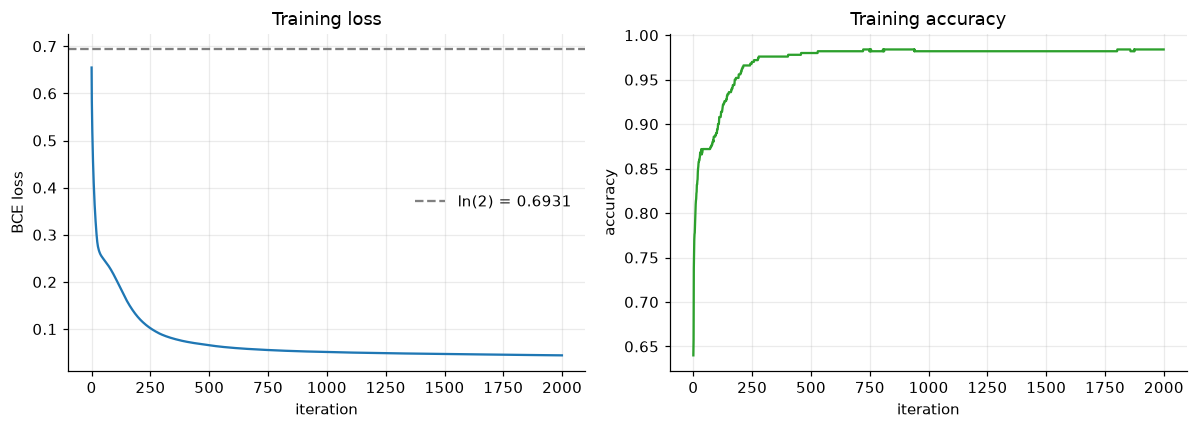

In [53]:
# ────────────────────────────────────────────────────────────────────
# 1) Two panels side by side: the loss on the left, the accuracy on the right.
# 2) Both against the iteration number. Label the axes.
# 3) Mark the starting loss — 0.6931 is the loss of a model that has learned
#    nothing on a balanced problem, and yours starts near it.
# Search: "matplotlib subplots two panels axhline"
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
#
# ١) لوحتان جنبًا إلى جنب: الخسارة يسارًا والدقة يمينًا.
# ٢) كلتاهما مقابل رقم التكرار. وسمِّ المحاور.
# ٣) أشِر إلى الخسارة الابتدائية — فـ ٠٫٦٩٣١ هي خسارة نموذج لم يتعلّم شيئًا في
#    مسألة متوازنة، وخسارتك تبدأ قربها.
# ابحث عن: "matplotlib subplots two panels axhline"
# ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# left panel: loss
axes[0].plot(history["iteration"], history["loss"], color="tab:blue")
axes[0].axhline(np.log(2), color="gray", linestyle="--", label="ln(2) = 0.6931")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Training loss")
axes[0].legend()

# right panel: accuracy
axes[1].plot(history["iteration"], history["accuracy"], color="tab:green")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Training accuracy")

plt.tight_layout()
plt.show()

The loss starts at 0.6931 — `ln 2`, the loss of a model that outputs 0.5 for everything, which is
exactly what an untrained network with zero biases does on a balanced problem. **Learn that number.**
On Sunday you will meet a flat curve sitting on it, and recognising it on sight will save you an hour
of tuning something that was never the problem.

Then look at the two panels together. The loss keeps falling smoothly for 2,000 iterations; the
accuracy jumps in steps and then sits still for hundreds of iterations at a time. They are measuring
different things: the loss cares how *confident* a correct answer was, and accuracy only cares which
side of 0.5 it landed. You optimise one and report the other, and that is not a compromise — it is
W3D3's slide 28 in a picture.

<div dir="rtl" align="right">

تبدأ الخسارة من ٠٫٦٩٣١ وهي `ln 2`، أي خسارة نموذج يُخرِج ٠٫٥ لكل شيء، وهذا بالضبط ما تفعله شبكة غير
مُدرَّبة بانحيازات صفرية في مسألة متوازنة. **احفظ هذا الرقم.** فيوم الأحد ستلقى منحنى مسطّحًا جالسًا
عليه، ومعرفتُه من النظرة الأولى ستوفّر عليك ساعة من ضبط شيء لم يكن هو المشكلة أصلًا.

ثم انظر في اللوحتين معًا. تواصل الخسارة هبوطها الناعم ألفَي تكرار، بينما تقفز الدقة درجاتٍ ثم تجلس
ساكنة مئات التكرارات في المرة. فهما تقيسان شيئين مختلفين: الخسارة يهمّها كم كان الجواب الصحيح
**واثقًا**، والدقة لا يهمّها إلا في أي جهة من ٠٫٥ وقع. فتُحسِّن واحدة وتعرض الأخرى، وهذه ليست مساومة
بل هي الشريحة ٢٨ في صورة.

</div>


### Task 2.5 — the boundary, before and after

Yesterday's picture and today's, side by side in one figure. Same data, same architecture, same 33
numbers — 2,000 updates apart.

Then the number that makes it a result rather than a picture: fit a `LogisticRegression` on the same
500 rows and compare. A logistic regression is the best **straight** boundary that exists for this
data. If your network beats it, the boundary you drew is doing something a straight line cannot,
and that is the claim this week has been building towards.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — الحدّ قبل وبعد

صورة الأمس وصورة اليوم جنبًا إلى جنب في شكل واحد. البيانات نفسها والمعمارية نفسها والأرقام الثلاثة
والثلاثون نفسها — بفارق ألفَي تحديث.

ثم الرقم الذي يجعلها نتيجة لا صورة: درّب `LogisticRegression` على الصفوف الخمسمئة نفسها وقارن.
فالانحدار اللوجستي هو أفضل حدّ **مستقيم** موجود لهذه البيانات. فإن تجاوزته شبكتك فالحدّ الذي رسمته
يفعل شيئًا لا يستطيعه خط مستقيم، وهذا هو الادعاء الذي يبنيه هذا الأسبوع.

</div>


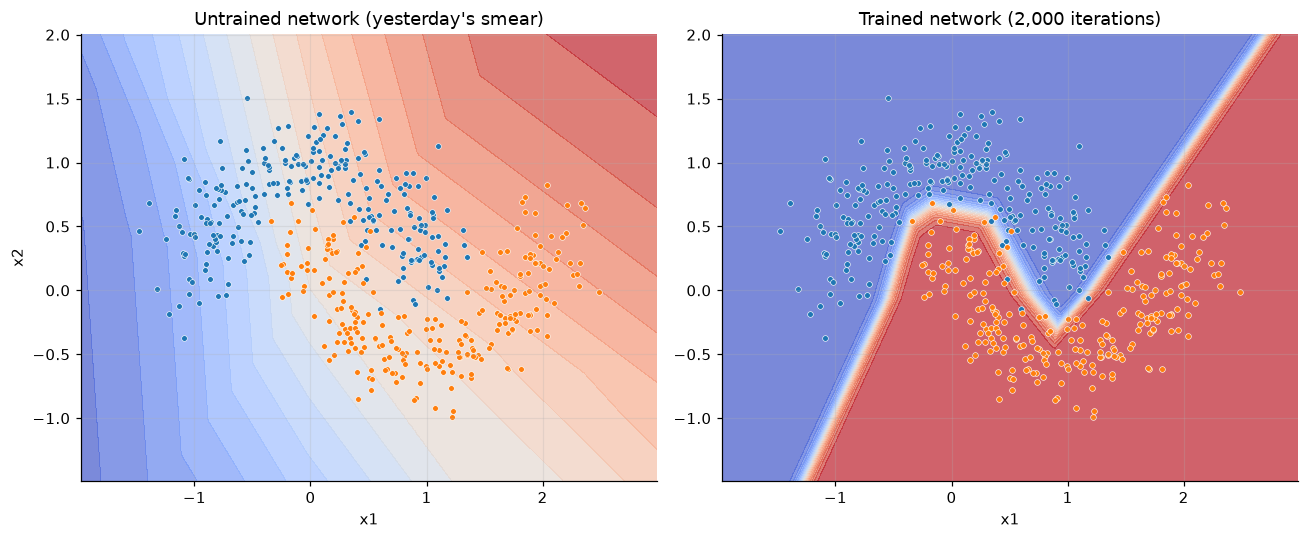

best straight boundary (logistic regression): 0.856
your network:                                 0.984
the curve is worth +0.128 of accuracy


In [54]:
# ────────────────────────────────────────────────────────────────────
# 1) Yesterday's plot_boundary, with an ax argument so two can share a figure.
#    Left panel: INITIAL_PARAMS. Right panel: the trained params.
# 2) Fit LogisticRegression on X and y.ravel(), and score it on the same rows.
# 3) Print both accuracies and the gap. The network should be ahead by about
#    12 points; if it is level, your training loop did not train.
# Search: "matplotlib subplots share figure contourf decision boundary"
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
#
# ١) دالة `plot_boundary` من الأمس مع وسيط `ax` ليتشارك اثنان شكلًا واحدًا.
#    اللوحة اليسرى: `INITIAL_PARAMS`. واليمنى: المعاملات المُدرَّبة.
# ٢) درّب `LogisticRegression` على `X` و`y.ravel()` وقِسه على الصفوف نفسها.
# ٣) اطبع الدقتين والفجوة. ويُتوقّع أن تتقدّم الشبكة بنحو ١٢ نقطة؛ فإن تعادلتا
#    فحلقة تدريبك لم تدرّب.
# ابحث عن: "matplotlib subplots share figure contourf decision boundary"
# ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression


def plot_boundary(params, title, ax):
    """Colour the plane by the network's output, then scatter the real points."""
    pad = 0.5
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 200),
        np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 200))
    surface, _ = forward(params, np.column_stack([xx.ravel(), yy.ravel()]))
    ax.contourf(xx, yy, surface.reshape(xx.shape), levels=20,
                cmap="coolwarm", alpha=0.7)
    for label, colour in ((0, PALETTE[0]), (1, PALETTE[1])):
        rows = y.ravel() == label
        ax.scatter(X[rows, 0], X[rows, 1], s=14, color=colour,
                   edgecolor="white", linewidth=0.4)
    ax.set_xlabel("x1")
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_boundary(INITIAL_PARAMS, "Untrained network (yesterday's smear)", axes[0])
plot_boundary(params, f"Trained network ({ITERATIONS:,} iterations)", axes[1])
axes[0].set_ylabel("x2")
plt.tight_layout()
plt.show()

logreg = LogisticRegression().fit(X, y.ravel())
linear_accuracy = float(logreg.score(X, y.ravel()))

print(f"best straight boundary (logistic regression): {linear_accuracy:.3f}")
print(f"your network:                                 {final_accuracy:.3f}")
print(f"the curve is worth {final_accuracy - linear_accuracy:+.3f} of accuracy")

## Section 3 — Stretch: measure what backpropagation saves  (≈30 min)

Open-ended. Lower expectation of completeness.

You have both implementations in front of you, so stop arguing about the cost and measure it.

Time one full `backward()` call. Then time a full numerical sweep — every parameter, two forward
passes each — and take the ratio. Then extrapolate: this network has 33 parameters, and a small real
network has 100,000. Multiply the measured per-parameter cost by 100,000 and report how long **one
training step** would take.

Then answer, in the cell after: at that speed, how long would 1,000 steps take, and what does that
tell you about whether the numerical method is a method at all?

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: قِس ما يوفّره الانتشار الخلفي (نحو ٣٠ دقيقة)

مفتوح. والتوقّع في الإكمال أقل.

التنفيذان أمامك، فكُفَّ عن الجدال في الثمن وقِسه.

قِس زمن نداء `backward()` كاملًا. ثم قِس زمن مسح عددي كامل — كل معامل ومرّان أماميان لكل منه — وخُذ
النسبة. ثم عمّم: في هذه الشبكة ٣٣ معاملًا، وفي شبكة حقيقية صغيرة ١٠٠٬٠٠٠. اضرب الكلفة المقيسة لكل
معامل في ١٠٠٬٠٠٠ واعرض كم تستغرق **خطوة تدريب واحدة**.

ثم أجب في الخليّة بعدها: بتلك السرعة، كم تستغرق ألف خطوة، وماذا يقول لك ذلك عن كون الطريقة العددية
طريقةً أصلًا؟

</div>


In [55]:
# ────────────────────────────────────────────────────────────────────
# 1) time.perf_counter() around each, and run the fast one several times so the
#    measurement is not dominated by timer noise.
# 2) The numerical sweep is the loop from task 2.3 without the comparison.
# 3) Scale it: seconds per parameter x 100,000 = one step of a small real network.
#    Print it in seconds, and then in whatever unit makes it readable.
# Search: "python time.perf_counter benchmark loop"
# https://docs.python.org/3/library/time.html#time.perf_counter
#
# ١) `time.perf_counter()` حول كل واحدة، وشغّل السريعة عدة مرات كي لا تسيطر ضوضاء
#    المؤقّت على القياس.
# ٢) المسح العددي هو حلقة المهمة ٢٫٣ بلا المقارنة.
# ٣) عمّمها: الثواني لكل معامل × ١٠٠٬٠٠٠ = خطوة واحدة لشبكة حقيقية صغيرة. واطبعها
#    بالثواني ثم بالوحدة التي تجعلها مقروءة.
# ابحث عن: "python time.perf_counter benchmark loop"
# ────────────────────────────────────────────────────────────────────

import time

REPEATS = 50
y_col = np.asarray(y).reshape(-1, 1)          # same shape as the output, no silent broadcasting

# analytic: one forward + backward, averaged over REPEATS
start = time.perf_counter()
for _ in range(REPEATS):
    out, cch = forward(params, X)
    _ = backward(params, cch, X, y_col, out)
analytic_seconds = (time.perf_counter() - start) / REPEATS

# numerical: the full sweep over every entry of every parameter array
sweep_params = {k: v.copy() for k, v in params.items()}   # work on a copy, keep params safe
start = time.perf_counter()
for key, array in sweep_params.items():
    for index in np.ndindex(array.shape):
        numerical_gradient(sweep_params, X, y_col, key, index)
numerical_seconds = time.perf_counter() - start

n_params = sum(array.size for array in params.values())
ratio = numerical_seconds / analytic_seconds
per_parameter = numerical_seconds / n_params
print(f"one forward + backward, all {n_params} gradients: "
      f"{analytic_seconds * 1000:.2f} ms")
print(f"the numerical sweep, all {n_params} gradients:    "
      f"{numerical_seconds * 1000:.2f} ms")
print(f"ratio: {ratio:.0f}x slower, for the same numbers")
print()
big = per_parameter * 100_000
print(f"at {per_parameter * 1000:.3f} ms per parameter, one training step of a "
      f"100,000-parameter network would cost {big:.0f} s ({big / 60:.1f} min)")
print(f"and 1,000 steps would take {big * 1000 / 3600:.1f} hours")

one forward + backward, all 33 gradients: 0.11 ms
the numerical sweep, all 33 gradients:    5.03 ms
ratio: 44x slower, for the same numbers

at 0.152 ms per parameter, one training step of a 100,000-parameter network would cost 15 s (0.3 min)
and 1,000 steps would take 4.2 hours


**Your two sentences:** _(is the numerical method slow, or is it not a method? And what is the one
thing it is still the right tool for?)_

<div dir="rtl" align="right">

**جملتاك:** _(هل الطريقة العددية بطيئة أم أنها ليست طريقة أصلًا؟ وما الشيء الوحيد الذي ما زالت هي
الأداة الصحيحة له؟)_

</div>


## Save your artefacts

Two files, and tomorrow needs both:

- **`numpy_net_history.parquet`** — one row per iteration: the loss and the accuracy. Tomorrow you
  plot PyTorch's curve on top of this one.
- **`numpy_net_params.npz`** — the weights this run **started** from and the weights it ended with.
  The starting weights are the important half: tomorrow's PyTorch network is loaded with these exact
  numbers, so that when the two loss curves agree to six decimals it is because the arithmetic is the
  same, and not because two random initialisations happened to be close.

<div dir="rtl" align="right">

## احفظ مخرجاتك

ملفان، والغد يحتاج كليهما:

- **`numpy_net_history.parquet`** وفيه صف لكل تكرار: الخسارة والدقة. وغدًا ترسم منحنى PyTorch فوق
  هذا المنحنى.
- **`numpy_net_params.npz`** وفيه الأوزان التي **بدأ** منها هذا التشغيل والأوزان التي انتهى إليها.
  والأوزان الابتدائية هي النصف المهمّ: فشبكة الغد بـ PyTorch تُحمَّل بهذه الأرقام بالضبط، حتى إذا
  توافق منحنيا الخسارة إلى ست خانات عشرية كان ذلك لأن الحساب واحد، لا لأن تهيئتين عشوائيتين تصادف
  تقاربهما.

</div>


In [56]:
history_path = ARTEFACT_DIR / "numpy_net_history.parquet"
history.to_parquet(history_path, index=False)

params_path = ARTEFACT_DIR / "numpy_net_params.npz"
np.savez(params_path,
         **{f"init_{k}": v for k, v in INITIAL_PARAMS.items()},
         **{f"final_{k}": v for k, v in params.items()},
         meta=np.array([N_IN, N_HIDDEN, N_OUT, ITERATIONS, LR, SEED], dtype=float))

reloaded_history = pd.read_parquet(history_path)
reloaded_params = np.load(params_path)

print(f"Saved {history_path}")
print(f"  {len(reloaded_history):,} rows, columns {list(reloaded_history.columns)}")
print(f"  loss {reloaded_history.iloc[0]['loss']:.4f} -> "
      f"{reloaded_history.iloc[-1]['loss']:.4f}")
print(f"\nSaved {params_path}")
print(f"  arrays: {sorted(reloaded_params.files)}")
print(f"  the initial weights survived the round trip: "
      f"{np.array_equal(reloaded_params['init_W1'], INITIAL_PARAMS['W1'])}")

Saved c:\Users\pc\AIEP_Olo_student\AIEP_Olo_student\week_3_neural_networks\labs\D3_backprop\artefacts\numpy_net_history.parquet
  2,000 rows, columns ['iteration', 'loss', 'accuracy']
  loss 0.6548 -> 0.0443

Saved c:\Users\pc\AIEP_Olo_student\AIEP_Olo_student\week_3_neural_networks\labs\D3_backprop\artefacts\numpy_net_params.npz
  arrays: ['final_W1', 'final_W2', 'final_b1', 'final_b2', 'init_W1', 'init_W2', 'init_b1', 'init_b2', 'meta']
  the initial weights survived the round trip: True


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

The third one is the one that matters: it fails if **any** of your 33 gradients disagrees with its
numerical counterpart. It does not average, and it does not sample. If it passes, your backward pass
is correct — and you know that rather than hoping it.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخليّة أخيرًا. كل فحص يفشل يخبرك بما تُصلحه ولماذا.

والفحص الثالث هو المهمّ: يفشل إن اختلف **أي** واحد من اشتقاقاتك الثلاثة والثلاثين عن نظيره العددي.
ولا يتوسّط ولا يأخذ عيّنة. فإن نجح فمرورك الخلفي صحيح — وأنت تعرف ذلك لا ترجوه.

</div>


In [59]:
# --- Sanity checks ----------------------------------------------------------------

check(np.isclose(loss_at_1, 0.0333, atol=5e-5)
      and np.isclose(loss_at_101, 0.0319, atol=5e-5)
      and np.isclose(one_sided, -0.134, atol=1e-3),
      f"the warm-up must reproduce the lecture: loss 0.0333 (got {loss_at_1:.4f}), "
      f"loss 0.0319 after the nudge (got {loss_at_101:.4f}), gradient -0.134 "
      f"(got {one_sided:.4f})",
      f"يجب أن تُعيد التهيئة إنتاج أرقام المحاضرة: خسارة ٠٫٠٣٣٣ (والناتج {loss_at_1:.4f})، "
      f"وخسارة ٠٫٠٣١٩ بعد التحريك (والناتج {loss_at_101:.4f})، واشتقاق ٠٫١٣٤− "
      f"(والناتج {one_sided:.4f})")

check(confident_wrong > 4 * confident_right,
      f"binary cross-entropy must punish a confident wrong answer far more than a hesitant "
      f"one — 0.1 cost {confident_wrong:.4f} and 0.9 cost {confident_right:.4f}, a ratio "
      f"of {confident_wrong / confident_right:.1f}x (it should be about 22)",
      f"يجب أن تعاقب الانتروبيا التقاطعية الجواب الخطأ الواثق أشدّ بكثير من المتردّد — "
      f"فكلفة ٠٫١ هي {confident_wrong:.4f} وكلفة ٠٫٩ هي {confident_right:.4f}، بنسبة "
      f"{confident_wrong / confident_right:.1f} (والمتوقّع نحو ٢٢)")

check(len(gradient_check) == 33 and worst < 1e-6,
      f"EVERY analytic gradient must match its numerical counterpart within 1e-6 — "
      f"{len(gradient_check)} were checked and the worst disagreement was {worst:.2e}. "
      f"A single mismatch means the backward pass is wrong somewhere.",
      f"يجب أن يطابق **كل** اشتقاق تحليلي نظيره العددي في حدود 1e-6 — فُحص منها "
      f"{len(gradient_check)} وأسوأ اختلاف كان {worst:.2e}. واختلاف واحد يعني أن المرور "
      f"الخلفي خطأ في موضع ما.")

first_hundred = history["loss"].diff().iloc[1:101]
check(bool((first_hundred < 0).all()),
      f"the loss must fall on every one of the first 100 iterations — it rose on "
      f"{int((first_hundred >= 0).sum())} of them. A rise this early means the learning "
      f"rate is too high or a gradient has the wrong sign.",
      f"يجب أن تهبط الخسارة في كل واحد من التكرارات المئة الأولى — وقد ارتفعت في "
      f"{int((first_hundred >= 0).sum())} منها. والارتفاع في هذا الوقت المبكر يعني أن معدّل "
      f"التعلّم مرتفع أو أن إشارة اشتقاق خطأ.")

check(0.85 < final_accuracy < 1.0,
      f"final accuracy on moons_toy should be above 0.85 and below 1.0 — got "
      f"{final_accuracy:.3f}. Exactly 1.0 would mean the noise=0.2 overlap vanished, "
      f"which is not possible on this data.",
      f"يجب أن تتجاوز الدقة النهائية على `moons_toy` قيمة ٠٫٨٥ وأن تقلّ عن ١٫٠ — والناتج "
      f"{final_accuracy:.3f}. و١٫٠ تامة تعني أن تداخل الضوضاء ٠٫٢ اختفى، وهذا غير ممكن على "
      f"هذه البيانات.")

check(final_accuracy > linear_accuracy + 0.05,
      f"the trained network must beat the best straight boundary by more than 5 points — "
      f"network {final_accuracy:.3f} vs logistic regression {linear_accuracy:.3f}. That "
      f"gap is the evidence that your boundary is genuinely non-linear.",
      f"يجب أن تتجاوز الشبكة المُدرَّبة أفضل حدّ مستقيم بأكثر من خمس نقاط — الشبكة "
      f"{final_accuracy:.3f} مقابل الانحدار اللوجستي {linear_accuracy:.3f}. وهذه الفجوة هي "
      f"الدليل على أن حدّك غير خطي فعلًا.")

check(history_path.exists() and params_path.exists()
      and len(reloaded_history) == ITERATIONS,
      f"both artefacts must be on disk with {ITERATIONS} recorded iterations — history "
      f"{history_path.exists()} with {len(reloaded_history)} rows, params "
      f"{params_path.exists()}",
      f"يجب أن يوجد الأثران على القرص وفيهما {ITERATIONS} تكرار مُسجَّل — السجلّ "
      f"{history_path.exists()} بـ {len(reloaded_history)} صفًا، والمعاملات "
      f"{params_path.exists()}")

report()

──────────────────────────────────────────────────────────────────
  ✓  the warm-up must reproduce the lecture: loss 0.0333 (got 0.0333), loss 0.0319 after the nudge (got 0.0319), gradient -0.134 (got -0.1336)
  ✓  binary cross-entropy must punish a confident wrong answer far more than a hesitant one — 0.1 cost 2.3026 and 0.9 cost 0.1054, a ratio of 21.9x (it should be about 22)
  ✓  EVERY analytic gradient must match its numerical counterpart within 1e-6 — 33 were checked and the worst disagreement was 8.65e-10. A single mismatch means the backward pass is wrong somewhere.
  ✓  the loss must fall on every one of the first 100 iterations — it rose on 0 of them. A rise this early means the learning rate is too high or a gradient has the wrong sign.
  ✓  final accuracy on moons_toy should be above 0.85 and below 1.0 — got 0.984. Exactly 1.0 would mean the noise=0.2 overlap vanished, which is not possible on this data.
  ✓  the trained network must beat the best straight boundary by more 

## What's next

You have written a backward pass and, more importantly, you have **proved** it correct. That second
part is the transferable skill: for the rest of your career, when you suspect a gradient, you now
know how to find out instead of guessing.

Tomorrow (**W3D4**) all of it gets deleted. You rebuild this network in PyTorch, load it with the
exact weights in `numpy_net_params.npz`, and confirm that `loss.backward()` prints the same
`−0.1360` and `−0.0544` you computed by hand — from a library that was never told how. Then you count
the lines you deleted, and every one of them will be from `backward()`.

Two things travel with you:

- **`numpy_net_history.parquet` and `numpy_net_params.npz`** — tomorrow's comparison is only honest
  because both runs start from the same numbers.
- **The gradient check itself.** `torch.autograd.gradcheck` is the library's version of the loop you
  wrote in task 2.3, and now you know exactly what it compares.

**A3 is issued today**, due W4D2. The mark is on your architecture justification and your training
curves; the held-out score is a floor, not the grade.

<div dir="rtl" align="right">

## ماذا بعد

كتبت مرورًا خلفيًا، والأهمّ أنك **أثبتّ** صحّته. وهذا الجزء الثاني هو المهارة المنقولة: فبقية حياتك
المهنية، حين تشكّ في اشتقاق، صرت تعرف كيف تتأكّد بدل أن تخمّن.

وغدًا (**الأسبوع ٣ اليوم ٤**) يُحذف هذا كله. تُعيد بناء الشبكة بـ PyTorch وتُحمّلها بالأوزان التي في
`numpy_net_params.npz` بالضبط، وتتأكّد أن `loss.backward()` يطبع `−0.1360` و`−0.0544` نفسيهما اللذين
حسبتهما بيدك — من مكتبة لم يُخبرها أحد كيف. ثم تعدّ الأسطر التي حذفتها، وستكون كلها من `backward()`.

وشيئان يسافران معك:

- **`numpy_net_history.parquet` و`numpy_net_params.npz`** — فمقارنة الغد لا تكون صادقة إلا لأن
  التشغيلين يبدآن من الأرقام نفسها.
- **فحص الاشتقاق نفسه.** فـ `torch.autograd.gradcheck` هو نسخة المكتبة من الحلقة التي كتبتها في
  المهمة ٢٫٣، وصرت تعرف بالضبط ما الذي يقارنه.

**ويُطرح التكليف الثالث اليوم** ويُسلَّم في الأسبوع الرابع اليوم الثاني. والدرجة على تبرير المعمارية
وعلى منحنيات التدريب، والنتيجة على البيانات المحجوزة أرضية لا درجة.

</div>
